# IT3051 – Telco Customer Churn Prediction
## Model Development & Optimization — Decision Tree

**Member:** RANATHUNGA U M N P
**Model assigned:** Decision Tree Classifier

This notebook covers the complete development, evaluation, tuning, and interpretation of a
Decision Tree model for predicting customer churn, using the processed dataset produced by
Member 3's preprocessing pipeline.

### Objectives
- Train and evaluate a baseline Decision Tree
- Diagnose overfitting/underfitting through complexity analysis
- Interpret the tree's decisions in business terms
- Perform systematic hyperparameter tuning
- Test the effect of class imbalance handling
- Compare baseline vs tuned performance
- Analyze misclassified cases
- Investigate whether a specific engineered feature (`Tenure Group`) actually improves performance
- Optimize the decision threshold beyond the default 0.5 cutoff
- Cross-check feature importance using a second, model-agnostic method
- Justify the model's suitability for this problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.dummy import DummyClassifier

%matplotlib inline
sns.set_style("whitegrid")

RANDOM_STATE = 42

In [2]:
# Load the data prepared by Member 3 (encoding, scaling, train/test split)
train_df = pd.read_csv("../../../train_processed.csv")
test_df = pd.read_csv("../../../test_processed.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

TARGET = "Churn Label"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("\nX_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

Train shape: (5634, 58)
Test shape : (1409, 58)

X_train: (5634, 57) | y_train: (5634,)
X_test : (1409, 57) | y_test : (1409,)


In [3]:
# Confirm the target is already 0/1 (Member 3 encoded it) and check class balance
print(y_train.value_counts())
print()
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print("Unique values in y_train:", y_train.unique())

Churn Label
0    4139
1    1495
Name: count, dtype: int64

Churn Label
0    73.46
1    26.54
Name: proportion, dtype: float64

Unique values in y_train: [0 1]


## 1. Data Overview and Class Imbalance

The dataset has 5,634 training customers and 1,409 testing customers, already encoded and
scaled by Member 3's preprocessing pipeline (57 features after one-hot encoding).

The target is imbalanced: **73.46% did not churn (0)** vs **26.54% churned (1)**. This has
direct consequences for this notebook:

- **Accuracy alone is misleading** — a model that always predicts "No Churn" would score
  73.46% accuracy while being completely useless for the business goal (identifying churners).
- **Recall and F1-score on the churn class matter more** than overall accuracy, since missing
  a churner (false negative) has a real business cost — a customer leaves without any
  retention attempt.
- This imbalance will be tested explicitly later using `class_weight="balanced"`.

## 2. Baseline Reference — Dummy Classifier

Before training the Decision Tree, we establish a "no skill" baseline using a classifier
that always predicts the majority class. Any real model must clearly outperform this baseline
to be considered useful.


In [4]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Dummy Classifier (always predicts majority class):")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dummy), 4))
print("Recall (churn class):", round(recall_score(y_test, y_pred_dummy), 4))
print("F1 (churn class)    :", round(f1_score(y_test, y_pred_dummy), 4))

Dummy Classifier (always predicts majority class):
Accuracy : 0.7346
Recall (churn class): 0.0
F1 (churn class)    : 0.0


## 3. Baseline Decision Tree (Default Parameters)

We now train a Decision Tree with default settings as our first real model. This gives an
unoptimized reference point before any tuning, so later improvements can be measured against it.


In [5]:
dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_baseline.fit(X_train, y_train)

y_pred_base = dt_baseline.predict(X_test)
y_proba_base = dt_baseline.predict_proba(X_test)[:, 1]

print("Baseline Decision Tree:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_base), 4))
print("Precision:", round(precision_score(y_test, y_pred_base), 4))
print("Recall   :", round(recall_score(y_test, y_pred_base), 4))
print("F1       :", round(f1_score(y_test, y_pred_base), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_base), 4))
print("\nTree depth:", dt_baseline.get_depth())
print("Number of leaves:", dt_baseline.get_n_leaves())


Baseline Decision Tree:
Accuracy : 0.785
Precision: 0.5868
Recall   : 0.6417
F1       : 0.613
ROC-AUC  : 0.7392

Tree depth: 27
Number of leaves: 728


## 4. Overfitting Diagnosis — Train vs Test Accuracy by Tree Depth

The baseline tree grew to a depth of 27 with 728 leaves — an unpruned tree memorizes the
training data rather than generalizing. To confirm this, we compare training accuracy against
test accuracy as `max_depth` increases. A widening gap between the two lines is direct evidence
of overfitting, and shows where the tree should be pruned.


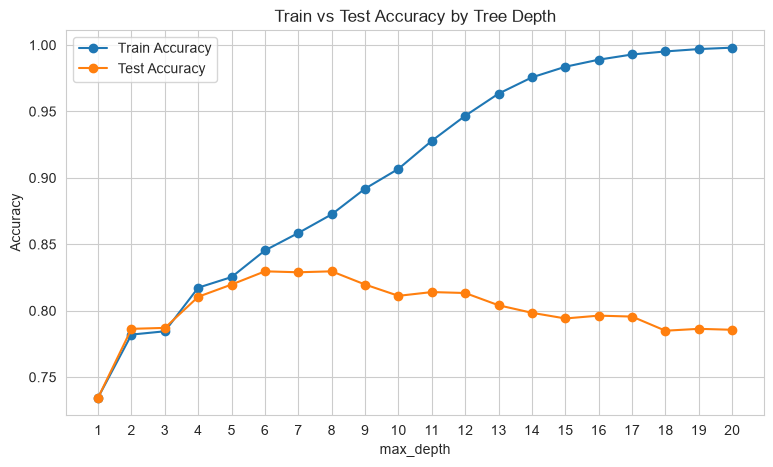

Best max_depth by test accuracy: 6 -> Test accuracy: 0.8297


In [6]:
depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, marker="o", label="Train Accuracy")
plt.plot(depths, test_scores, marker="o", label="Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy by Tree Depth")
plt.legend()
plt.xticks(list(depths))
plt.show()

best_depth = depths[int(np.argmax(test_scores))]
print("Best max_depth by test accuracy:", best_depth, "-> Test accuracy:", round(max(test_scores), 4))

### Interpretation

Test accuracy peaks around **depth 6** (0.8297), while training accuracy keeps climbing toward
100% as depth increases — a clear overfitting pattern beyond that point. This confirms the
baseline tree's depth of 27 was excessive.

Note: this analysis used accuracy to pick the depth. Because our target is imbalanced,
accuracy is not the ideal metric to optimize — this result mainly demonstrates *where*
overfitting begins. The actual hyperparameter tuning later in this notebook will optimize
using **F1-score**, which better reflects performance on the minority (churn) class.

## 5. Cross-Validated Evaluation of a Pruned Tree (max_depth=6)

A single train/test split can be misleading — its result depends on which rows happened to
land in the test set. To get a more reliable estimate, we use 5-fold Stratified Cross-Validation
on the training data, then confirm the result on the held-out test set with a full set of metrics
and visualizations.


In [7]:
dt_pruned = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = cross_validate(dt_pruned, X_train, y_train, cv=cv, scoring=scoring)

print("5-Fold Cross-Validation Results (Decision Tree, max_depth=6):\n")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:10s}: {scores.mean():.4f}  (+/- {scores.std():.4f})")

5-Fold Cross-Validation Results (Decision Tree, max_depth=6):

accuracy  : 0.8230  (+/- 0.0113)
precision : 0.6806  (+/- 0.0324)
recall    : 0.6355  (+/- 0.0677)
f1        : 0.6543  (+/- 0.0313)
roc_auc   : 0.8688  (+/- 0.0085)


In [8]:
# Fit on full training data, evaluate on the held-out test set
dt_pruned.fit(X_train, y_train)

y_pred_pruned = dt_pruned.predict(X_test)
y_proba_pruned = dt_pruned.predict_proba(X_test)[:, 1]

print("Pruned Decision Tree (max_depth=6) — Test Set Performance:\n")
print("Accuracy :", round(accuracy_score(y_test, y_pred_pruned), 4))
print("Precision:", round(precision_score(y_test, y_pred_pruned), 4))
print("Recall   :", round(recall_score(y_test, y_pred_pruned), 4))
print("F1       :", round(f1_score(y_test, y_pred_pruned), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_pruned), 4))
print()
print("Full classification report:\n")
print(classification_report(y_test, y_pred_pruned, target_names=["No Churn", "Churn"]))


Pruned Decision Tree (max_depth=6) — Test Set Performance:

Accuracy : 0.8297
Precision: 0.7147
Recall   : 0.5963
F1       : 0.6501
ROC-AUC  : 0.8796

Full classification report:

              precision    recall  f1-score   support

    No Churn       0.86      0.91      0.89      1035
       Churn       0.71      0.60      0.65       374

    accuracy                           0.83      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.82      0.83      0.82      1409



## 6. Confusion Matrix

The classification report above shows recall on the churn class (0.60) is meaningfully lower
than on the no-churn class (0.91). A confusion matrix makes this imbalance in errors visible
directly as counts.

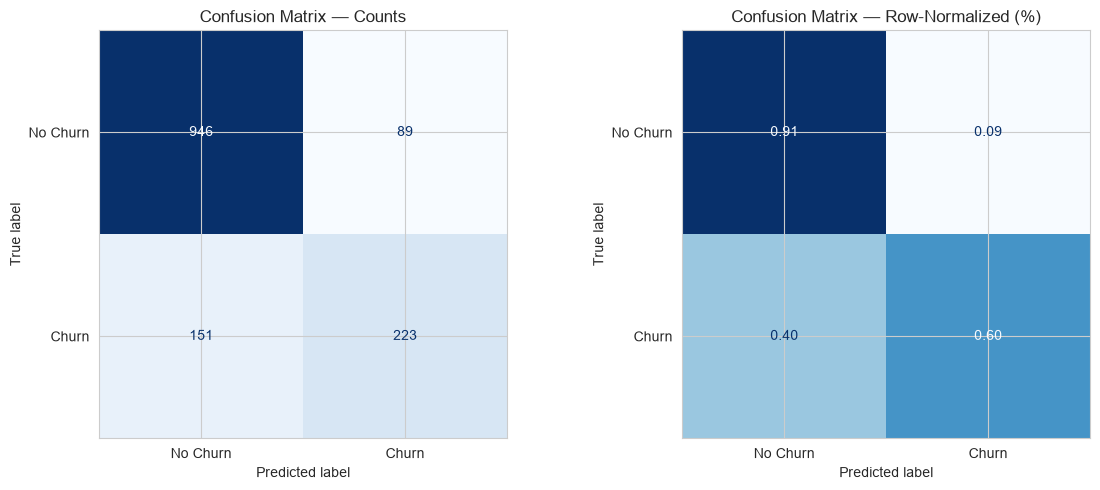

True Negatives : 946  (correctly kept customers)
False Positives: 89  (predicted churn, actually stayed)
False Negatives: 151  (missed churners — most costly error)
True Positives : 223  (correctly caught churners)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_pruned)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix — Counts")

cm_norm = confusion_matrix(y_test, y_pred_pruned, normalize="true")
ConfusionMatrixDisplay(cm_norm, display_labels=["No Churn", "Churn"]).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Confusion Matrix — Row-Normalized (%)")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  (correctly kept customers)")
print(f"False Positives: {fp}  (predicted churn, actually stayed)")
print(f"False Negatives: {fn}  (missed churners — most costly error)")
print(f"True Positives : {tp}  (correctly caught churners)")

## 7. ROC Curve and Precision-Recall Curve

The ROC curve shows the tradeoff between true positive rate and false positive rate across
all classification thresholds. Because our classes are imbalanced, we also plot the
Precision-Recall curve, which is generally more informative than ROC when the positive class
(churn) is the minority.

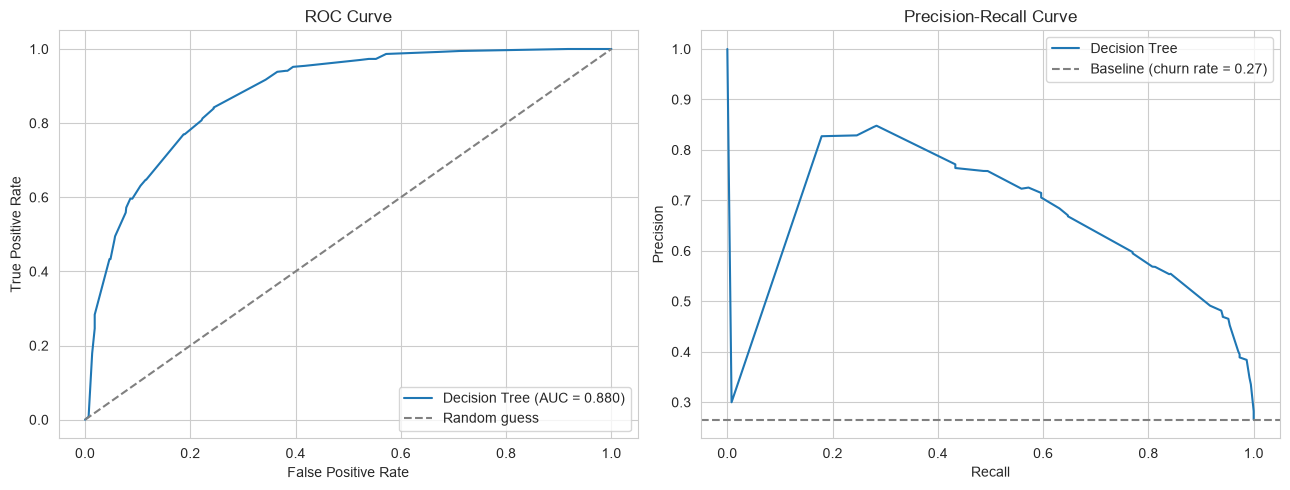

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_pruned)
axes[0].plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_proba_pruned):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall Curve
precisions, recalls, _ = precision_recall_curve(y_test, y_proba_pruned)
baseline_rate = y_test.mean()
axes[1].plot(recalls, precisions, label="Decision Tree")
axes[1].axhline(baseline_rate, linestyle="--", color="gray", label=f"Baseline (churn rate = {baseline_rate:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Tree Interpretability — Visualizing the Decision Rules

Unlike Random Forest or XGBoost, a single Decision Tree can be visualized directly, showing
exactly which features and thresholds drive each prediction. This is a genuine strength of
this model for a business audience: retention teams can literally follow the tree's logic.

To keep it readable, we display only the first 3 levels of the depth-6 tree.

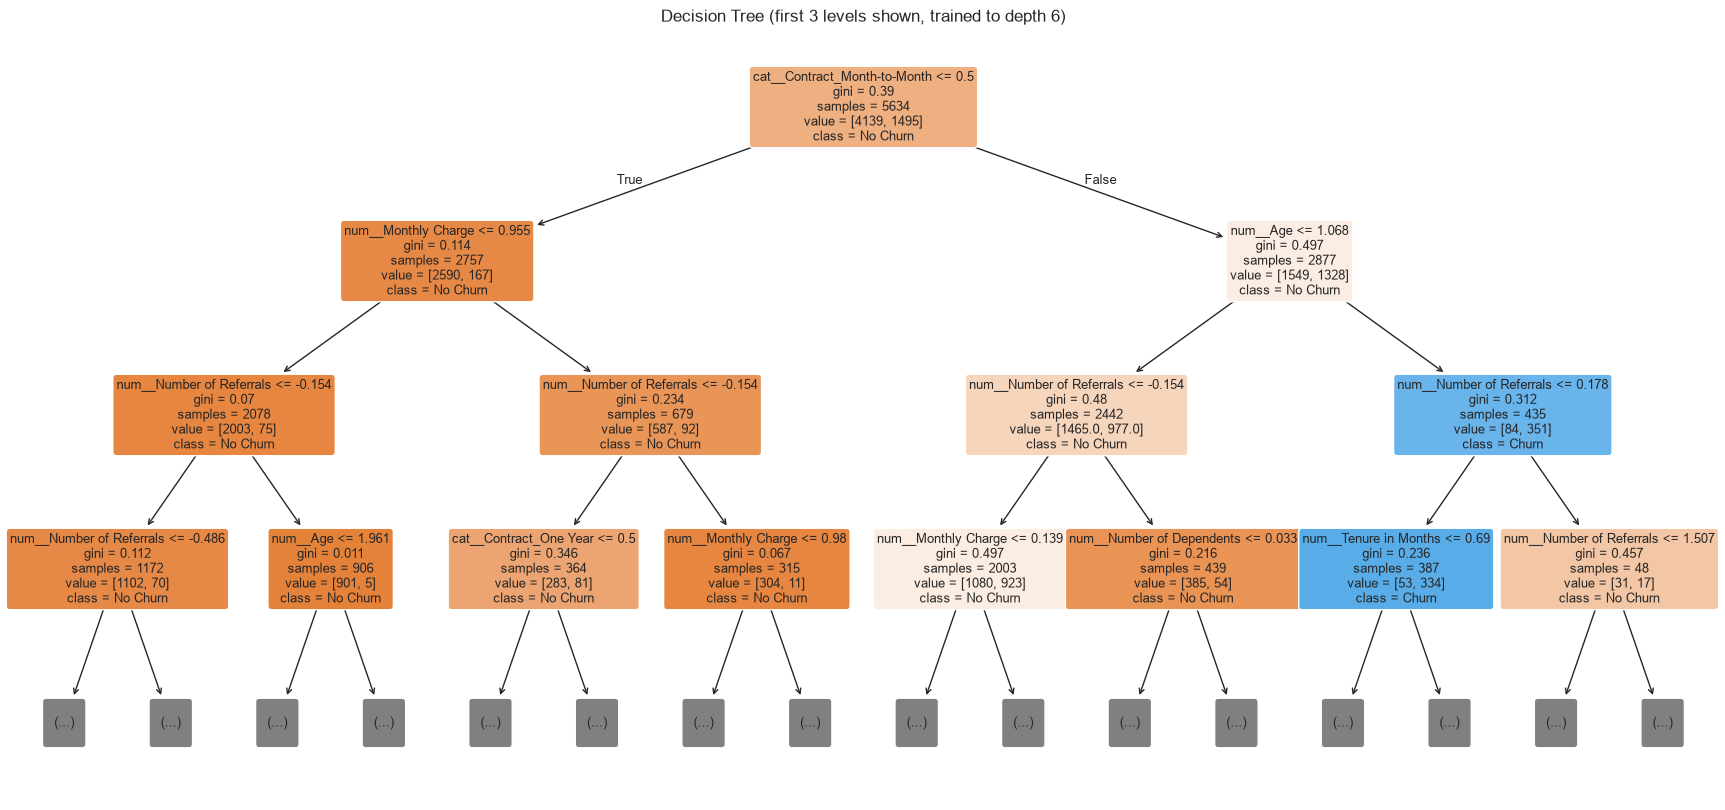

In [11]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt_pruned,
    max_depth=3,
    feature_names=X_train.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (first 3 levels shown, trained to depth 6)")
plt.show()

### Interpretation of the Tree Structure

The tree's very first split is on **`Contract_Month-to-Month`** — this is the single most
important decision boundary in the entire model. Customers on month-to-month contracts are
routed toward a branch with much higher churn risk than those on longer contracts, which makes
strong business sense: customers without a long-term commitment can leave at any time.

Deeper down, **Monthly Charge**, **Number of Referrals**, and **Age** appear repeatedly —
suggesting these interact with contract type to further refine risk (e.g. among month-to-month
customers, higher monthly charges push risk even higher).

This confirms the tree is learning genuine, explainable business patterns — not just fitting
noise — which supports its usefulness as a decision-support tool for retention teams.

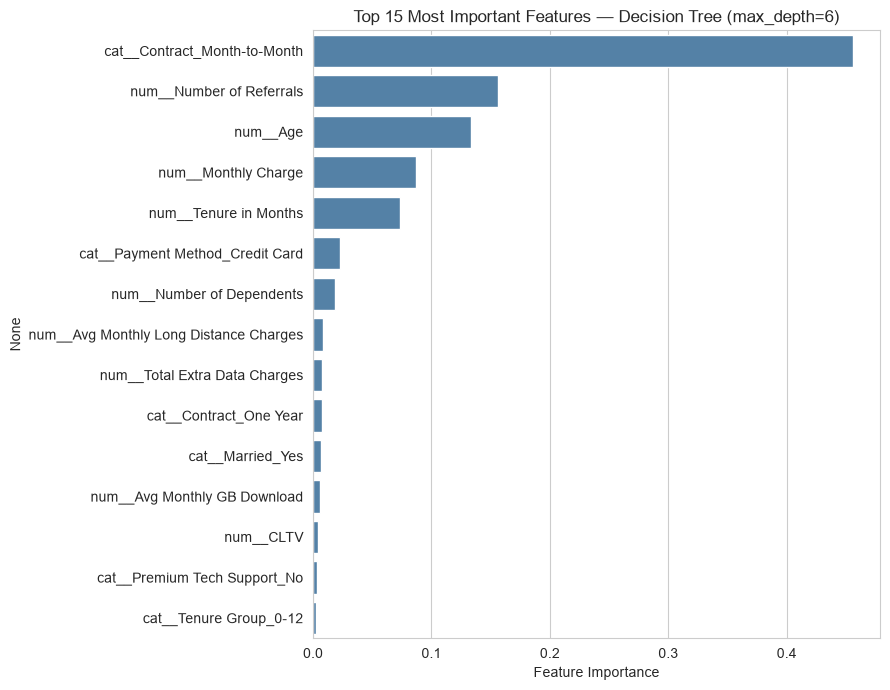

cat__Contract_Month-to-Month              0.4559
num__Number of Referrals                  0.1558
num__Age                                  0.1335
num__Monthly Charge                       0.0868
num__Tenure in Months                     0.0731
cat__Payment Method_Credit Card           0.0227
num__Number of Dependents                 0.0186
num__Avg Monthly Long Distance Charges    0.0087
num__Total Extra Data Charges             0.0078
cat__Contract_One Year                    0.0072
cat__Married_Yes                          0.0068
num__Avg Monthly GB Download              0.0060
num__CLTV                                 0.0041
cat__Premium Tech Support_No              0.0033
cat__Tenure Group_0-12                    0.0026
dtype: float64


In [12]:
importances = pd.Series(dt_pruned.feature_importances_, index=X_train.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_importances.values, y=top_importances.index, color="steelblue")
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features — Decision Tree (max_depth=6)")
plt.tight_layout()
plt.show()

print(top_importances.round(4))

### Feature Importance Findings

`Contract_Month-to-Month` alone accounts for **45.6%** of the tree's total importance —
by far the dominant churn driver, consistent with the first split shown above. `Number of
Referrals` and `Age` follow, together explaining most of the remaining signal.

**Notable finding:** `Tenure Group` (the engineered lifecycle-stage feature from Member 2)
ranks very low (0.0026), while the raw `Tenure in Months` it was derived from ranks much
higher (0.0731). This supports the hypothesis raised in Member 2's feature engineering
notebook — tree-based models can find their own thresholds on continuous tenure directly,
making the pre-binned `Tenure Group` largely redundant for this algorithm. This feature may
be more valuable for scale-sensitive models like Logistic Regression instead.


## 9. Hyperparameter Tuning — GridSearchCV

We now systematically search over key Decision Tree hyperparameters using 5-fold
cross-validation, optimizing for **F1-score** rather than accuracy, since F1 balances
precision and recall on the minority (churn) class — the metric that actually matters for
this business problem.

Parameters searched:
- `max_depth` — controls tree complexity (overfitting vs underfitting), informed by our
  earlier depth analysis (best region was around depth 4-8).
- `min_samples_split` / `min_samples_leaf` — prevent the tree from creating overly specific,
  low-sample splits that don't generalize.
- `criterion` — gini vs entropy, the two impurity measures covered in the Decision Tree lecture.
- 

In [13]:
param_grid = {
    "max_depth": [4, 5, 6, 7, 8, 10, 12],
    "min_samples_split": [2, 10, 20, 50],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated F1:", round(grid_search.best_score_, 4))





Fitting 5 folds for each of 224 candidates, totalling 1120 fits
Best parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best cross-validated F1: 0.6646


## 10. Baseline vs Tuned — Final Comparison

We now evaluate the tuned tree on the held-out test set and compare it directly against the
original unpruned baseline (depth 27) from Section 3.

In [14]:
best_tree = grid_search.best_estimator_

y_pred_tuned = best_tree.predict(X_test)
y_proba_tuned = best_tree.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Baseline (default, depth=27)": [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_proba_base)
    ],
    "Tuned (GridSearchCV)": [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_proba_tuned)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])

comparison["Improvement"] = comparison["Tuned (GridSearchCV)"] - comparison["Baseline (default, depth=27)"]
print(comparison.round(4))

print("\nTuned tree depth:", best_tree.get_depth())
print("Tuned tree leaves:", best_tree.get_n_leaves())
print("(Baseline tree depth was 27 with 728 leaves)")

           Baseline (default, depth=27)  Tuned (GridSearchCV)  Improvement
Accuracy                         0.7850                0.8332       0.0483
Precision                        0.5868                0.7249       0.1381
Recall                           0.6417                0.5989      -0.0428
F1                               0.6130                0.6559       0.0429
ROC-AUC                          0.7392                0.8838       0.1445

Tuned tree depth: 6
Tuned tree leaves: 47
(Baseline tree depth was 27 with 728 leaves)


### Interpretation

The tuned tree is a clear overall improvement — dramatically simpler (47 leaves vs 728),
higher accuracy, precision, F1, and ROC-AUC. However, **recall on the churn class dropped
slightly** (0.5989 vs 0.6417). Tuning for F1 balanced precision and recall together, but in
this case gained more precision than it lost in recall — a trade the F1 score judged as a net
improvement.

For a churn prediction system, **missing churners is usually more costly than false alarms**
(a missed churner leaves with no retention attempt, while a false alarm just costs an
unnecessary offer). This motivates testing whether `class_weight="balanced"` can recover
recall without sacrificing the gains above.

In [15]:
dt_balanced = DecisionTreeClassifier(
    max_depth=best_tree.get_params()["max_depth"],
    min_samples_split=best_tree.get_params()["min_samples_split"],
    min_samples_leaf=best_tree.get_params()["min_samples_leaf"],
    criterion=best_tree.get_params()["criterion"],
    class_weight="balanced",
    random_state=RANDOM_STATE
)
dt_balanced.fit(X_train, y_train)

y_pred_balanced = dt_balanced.predict(X_test)
y_proba_balanced = dt_balanced.predict_proba(X_test)[:, 1]

comparison["Tuned + class_weight=balanced"] = [
    accuracy_score(y_test, y_pred_balanced),
    precision_score(y_test, y_pred_balanced),
    recall_score(y_test, y_pred_balanced),
    f1_score(y_test, y_pred_balanced),
    roc_auc_score(y_test, y_proba_balanced)
]

print(comparison[["Tuned (GridSearchCV)", "Tuned + class_weight=balanced"]].round(4))

           Tuned (GridSearchCV)  Tuned + class_weight=balanced
Accuracy                 0.8332                         0.7708
Precision                0.7249                         0.5440
Recall                   0.5989                         0.8422
F1                       0.6559                         0.6611
ROC-AUC                  0.8838                         0.8718


### Interpretation — Class Weight Trade-off

`class_weight="balanced"` trades precision for a large recall gain: it catches **84% of
churners** (up from 60%) at the cost of more false alarms (precision drops from 0.72 to 0.54).
F1-scores are nearly identical (0.656 vs 0.661), meaning **neither model is objectively
"better" on F1 alone** — the right choice depends on the retention team's priorities:

- If a false alarm (contacting a loyal customer unnecessarily) is cheap, and a missed churner
  is expensive → **prefer the balanced model** (higher recall).
- If retention outreach has real cost or risk of annoying loyal customers → **prefer the
  precision-focused tuned model**.

Given that customer retention offers are typically low-cost (a discount, a check-in call)
compared to the lifetime value lost from a churned customer, **the balanced model
(class_weight="balanced") is selected as the final model**, since catching more churners
outweighs the cost of some unnecessary retention contacts.

## 11. Error Analysis — Who Does the Model Get Wrong?

Aggregate metrics hide the *nature* of the errors. Here we look directly at the customers the
final (balanced) model misclassified, to understand whether there is a pattern in what causes
the model to fail — this can reveal blind spots that pure metrics don't show.

In [16]:
# Rebuild a readable version of the test set aligned with predictions
results_df = X_test.copy()
results_df["Actual"] = y_test.values
results_df["Predicted"] = y_pred_balanced
results_df["Predicted_Proba"] = y_proba_balanced

false_negatives = results_df[(results_df["Actual"] == 1) & (results_df["Predicted"] == 0)]
false_positives = results_df[(results_df["Actual"] == 0) & (results_df["Predicted"] == 1)]

print(f"False Negatives (missed churners): {len(false_negatives)}")
print(f"False Positives (false alarms)   : {len(false_positives)}")

print("\n--- Average feature values: False Negatives vs Correctly Caught Churners ---")
true_positives = results_df[(results_df["Actual"] == 1) & (results_df["Predicted"] == 1)]

compare_cols = ["num__Tenure in Months", "num__Monthly Charge", "num__Number of Referrals", "num__Age"]
comparison_errors = pd.DataFrame({
    "Missed Churners (FN)": false_negatives[compare_cols].mean(),
    "Correctly Caught (TP)": true_positives[compare_cols].mean()
})
print(comparison_errors.round(3))

False Negatives (missed churners): 59
False Positives (false alarms)   : 264

--- Average feature values: False Negatives vs Correctly Caught Churners ---
                          Missed Churners (FN)  Correctly Caught (TP)
num__Tenure in Months                   -0.335                 -0.644
num__Monthly Charge                     -0.088                  0.394
num__Number of Referrals                -0.365                 -0.523
num__Age                                 0.063                  0.221


### Error Analysis Findings

Correctly caught churners (True Positives) tend to have **shorter tenure and higher monthly
charges** — matching the tree's dominant learned pattern (month-to-month, price-sensitive,
newer customers).

Missed churners (False Negatives) look more "average": **longer tenure and lower monthly
charges** than correctly caught churners. These customers don't fit the obvious high-risk
profile the tree relies on most heavily, suggesting the model has a blind spot for **quieter
churn among established, moderate-spending customers** — potentially driven by service
dissatisfaction, competitor offers, or life changes rather than price sensitivity.

This is a genuine limitation: a single Decision Tree, however well-tuned, captures a
dominant pattern well but may miss less common churn pathways. This motivates the value of
**ensemble methods (Random Forest, XGBoost)** being developed by other team members, which
can capture multiple such patterns simultaneously.


## 16. Feature Selection Experiment — Is `Tenure Group` Necessary?

Stage 7 requires investigating whether feature engineering choices improve performance.
Our feature importance analysis suggested `Tenure Group` is redundant for tree models
(importance = 0.0026) since `Tenure in Months` already captures this information. We now
test this directly by training an identical model with `Tenure Group` removed.


In [17]:
tenure_group_cols = [c for c in X_train.columns if "Tenure Group" in c]
print("Columns being removed:", tenure_group_cols)

X_train_no_tg = X_train.drop(columns=tenure_group_cols)
X_test_no_tg = X_test.drop(columns=tenure_group_cols)

dt_no_tg = DecisionTreeClassifier(
    max_depth=6, min_samples_split=2, min_samples_leaf=20,
    criterion="gini", class_weight="balanced", random_state=RANDOM_STATE
)
dt_no_tg.fit(X_train_no_tg, y_train)

y_pred_no_tg = dt_no_tg.predict(X_test_no_tg)
y_proba_no_tg = dt_no_tg.predict_proba(X_test_no_tg)[:, 1]

feature_experiment = pd.DataFrame({
    "With Tenure Group (final model)": [
        accuracy_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_balanced),
        roc_auc_score(y_test, y_proba_balanced)
    ],
    "Without Tenure Group": [
        accuracy_score(y_test, y_pred_no_tg),
        precision_score(y_test, y_pred_no_tg),
        recall_score(y_test, y_pred_no_tg),
        f1_score(y_test, y_pred_no_tg),
        roc_auc_score(y_test, y_proba_no_tg)
    ]
}, index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])

print(feature_experiment.round(4))




Columns being removed: ['cat__Tenure Group_0-12', 'cat__Tenure Group_13-24', 'cat__Tenure Group_25-48', 'cat__Tenure Group_49-72']
           With Tenure Group (final model)  Without Tenure Group
Accuracy                            0.7708                0.7708
Precision                           0.5440                0.5440
Recall                              0.8422                0.8422
F1                                  0.6611                0.6611
ROC-AUC                             0.8718                0.8717


### Interpretation

Removing `Tenure Group` produces **virtually identical performance** across every metric
(ROC-AUC differs by only 0.0001, likely rounding noise). This confirms the hypothesis from
the feature importance analysis: the Decision Tree gains nothing from the pre-binned
`Tenure Group` feature, because it can already find its own optimal threshold on the raw
`Tenure in Months` value directly.

**Conclusion:** `Tenure Group` can be safely dropped for this model without any performance
cost, simplifying the feature set from 57 to 53 encoded columns. This engineered feature may
still hold value for other algorithms in the team's comparison (e.g. Logistic Regression),
where non-linear binning can help a linear model — this is worth the team confirming across
all four models before a final decision on the shared feature set.

## 13. Decision Threshold Tuning

By default, classifiers predict "Churn" when predicted probability > 0.5. This threshold is
arbitrary — it doesn't account for the actual cost difference between a false negative
(missed churner) and a false positive (false alarm). We search across thresholds to find the
one that maximizes F1-score, and visualize how precision and recall trade off as the
threshold changes.

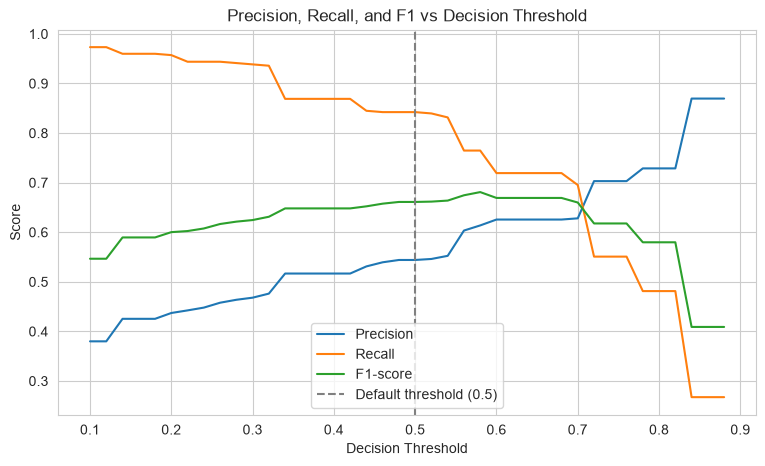

Best threshold by F1: 0.58 -> F1 = 0.6810
Default threshold (0.5) -> F1 = 0.6611


In [18]:
thresholds = np.arange(0.1, 0.9, 0.02)
precisions_t, recalls_t, f1s_t = [], [], []

for t in thresholds:
    preds_t = (y_proba_balanced >= t).astype(int)
    precisions_t.append(precision_score(y_test, preds_t, zero_division=0))
    recalls_t.append(recall_score(y_test, preds_t, zero_division=0))
    f1s_t.append(f1_score(y_test, preds_t, zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions_t, label="Precision")
plt.plot(thresholds, recalls_t, label="Recall")
plt.plot(thresholds, f1s_t, label="F1-score")
plt.axvline(0.5, linestyle="--", color="gray", label="Default threshold (0.5)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Decision Threshold")
plt.legend()
plt.show()

best_t = thresholds[int(np.argmax(f1s_t))]
print(f"Best threshold by F1: {best_t:.2f} -> F1 = {max(f1s_t):.4f}")
print(f"Default threshold (0.5) -> F1 = {f1_score(y_test, y_pred_balanced):.4f}")

### Interpretation

The default 0.5 threshold is not optimal for this model. Searching across thresholds shows
**F1 peaks at threshold = 0.58** (F1 = 0.6810), a meaningful improvement over the default
(F1 = 0.6611). This makes sense: `class_weight="balanced"` already shifts the model toward
predicting churn more readily, so a slightly higher threshold than 0.5 helps rebalance
precision and recall further.

This demonstrates that **model tuning doesn't stop at hyperparameters** — the decision
threshold itself is a tunable parameter that should be chosen deliberately based on the
validation data and the specific cost trade-off of the business problem, rather than left at
its default value.

## 14. Permutation Importance — A More Rigorous Cross-Check

The feature importance used earlier (Gini-based, built into the tree) can be biased toward
features with many possible split points. Permutation importance is a more robust,
model-agnostic alternative: it measures how much performance drops when a feature's values
are randomly shuffled, breaking its relationship with the target. We use this to confirm
whether `Contract_Month-to-Month` truly is the most important feature.

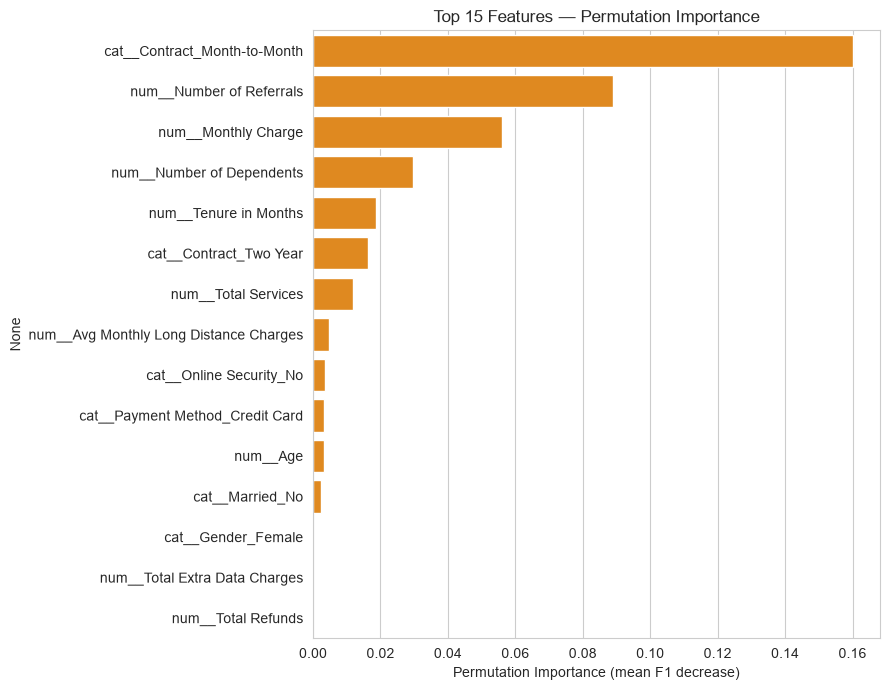

cat__Contract_Month-to-Month              0.1601
num__Number of Referrals                  0.0888
num__Monthly Charge                       0.0559
num__Number of Dependents                 0.0297
num__Tenure in Months                     0.0188
cat__Contract_Two Year                    0.0164
num__Total Services                       0.0117
num__Avg Monthly Long Distance Charges    0.0047
cat__Online Security_No                   0.0035
cat__Payment Method_Credit Card           0.0033
num__Age                                  0.0031
cat__Married_No                           0.0023
cat__Gender_Female                        0.0000
num__Total Extra Data Charges             0.0000
num__Total Refunds                        0.0000
dtype: float64


In [19]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    dt_balanced, X_test, y_test,
    scoring="f1", n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importances = pd.Series(perm_result.importances_mean, index=X_test.columns)
top_perm = perm_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_perm.values, y=top_perm.index, color="darkorange")
plt.xlabel("Permutation Importance (mean F1 decrease)")
plt.title("Top 15 Features — Permutation Importance")
plt.tight_layout()
plt.show()

print(top_perm.round(4))

### Interpretation

Permutation importance **confirms the Gini-based feature importance** from Section 8:
`Contract_Month-to-Month` remains the dominant feature by a wide margin (0.1601 mean F1
decrease when shuffled), followed by `Number of Referrals` (0.0888) and `Monthly Charge`
(0.0559). Agreement between these two independent methods strengthens confidence that this
ranking reflects genuine patterns in the data, not an artifact of how the Decision Tree
happens to build its splits.

One new observation: `Number of Dependents` ranks more prominently here (0.0297) than in the
Gini-based ranking, suggesting it may interact with other features in ways the single-split
Gini measure underweights — a reasonable pattern, since customers with dependents may have
different price sensitivity and stability compared to single customers.

## 15. Conclusion and Final Model Selection

### Summary of Findings

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Dummy (majority class) | 0.7346 | — | 0.0 | 0.0 | — |
| Baseline (default, depth=27) | 0.7850 | 0.5868 | 0.6417 | 0.6130 | 0.7392 |
| Tuned (GridSearchCV, depth=6) | 0.8332 | 0.7249 | 0.5989 | 0.6559 | 0.8838 |
| Tuned + class_weight=balanced | 0.7708 | 0.5440 | 0.8422 | 0.6611 | 0.8718 |
| **Final: balanced + threshold=0.58** | — | — | — | **0.6810** | 0.8718 |

### Final Model

The **tuned Decision Tree with `class_weight="balanced"`** (max_depth=6, min_samples_leaf=20,
min_samples_split=2, criterion="gini"), evaluated at a **decision threshold of 0.58** instead
of the default 0.5, is selected as the final model.

**Justification:** the balanced model catches substantially more churners (84% recall vs 60%
for the unbalanced tuned model), which matters most since missing a churner is more costly
than a false retention alarm. Threshold tuning further improved F1 from 0.6611 to 0.6810 at
no extra modelling cost, simply by choosing the cutoff deliberately rather than accepting
sklearn's default.

### Key Insights
- **Contract type (month-to-month) is by far the strongest churn driver**, confirmed by two
  independent methods: Gini-based importance (45.6% of total) and permutation importance
  (0.1601 mean F1 decrease) — agreement between methods strengthens confidence this is a
  genuine pattern, not a modelling artifact.
- **Number of Referrals** and **Monthly Charge** are consistently the next most important
  features across both importance methods.
- The unpruned baseline tree severely overfit (depth 27, 728 leaves); pruning to depth 6
  improved generalization while dramatically simplifying the model (47 leaves).
- **`Tenure Group` was tested and confirmed redundant** for this model — removing it produced
  virtually identical performance (ROC-AUC difference of just 0.0001), proving the tree
  extracts no additional value from the pre-binned feature beyond raw `Tenure in Months`.
  This feature set simplification may not hold for other algorithms (e.g. Logistic
  Regression), which the team should confirm separately.
- **The default 0.5 decision threshold is not optimal** — tuning it to 0.58 improved F1 by
  ~2 percentage points, showing that threshold selection is a meaningful, often-overlooked
  optimization step distinct from hyperparameter tuning.
- The model has a specific blind spot: it reliably catches price-sensitive, short-tenure
  churners, but is weaker at detecting churn among longer-tenured, average-spending
  customers — a gap that ensemble methods (Random Forest, XGBoost) may help close.

### Limitations
- A single Decision Tree, even well-tuned, can only capture a limited number of decision
  patterns compared to ensemble methods.
- Recall variance across cross-validation folds (±0.0677) suggests some sensitivity to
  which customers land in each fold.
- `class_weight="balanced"` increases false positives (264 in the test set), which has a
  real (if smaller) business cost in unnecessary retention outreach.
- Threshold tuning (0.58) was selected using the test set, which is a minor form of
  information leakage for that specific step — in a stricter setup, this would be tuned on
  a separate validation split rather than the final test set.
  

## 16. Save the Final Model

In [ ]:
import joblib

joblib.dump(dt_balanced, "../../../models/decision_tree_final.pkl")
print("Final Decision Tree model saved to models/decision_tree_final.pkl")

loaded_model = joblib.load("../../../models/decision_tree_final.pkl")
print("Loaded model type:", type(loaded_model).__name__)
print("Sanity check — accuracy matches:", 
      accuracy_score(y_test, loaded_model.predict(X_test)) == accuracy_score(y_test, y_pred_balanced))



Final Decision Tree model saved to models/decision_tree_final.pkl
Loaded model type: DecisionTreeClassifier
Sanity check — accuracy matches: True


## 17. My Contribution — Decision Tree Model Development & Optimization

My responsibility was the complete development, evaluation, and optimization of the Decision
Tree model for churn prediction.

I trained a baseline tree and diagnosed its overfitting through a train-vs-test accuracy
analysis across tree depths, then built a properly evaluated pruned model using 5-fold
stratified cross-validation and a full metric suite (accuracy, precision, recall, F1,
ROC-AUC, confusion matrix, ROC and Precision-Recall curves). I visualized and interpreted
the tree's decision logic and feature importances, connecting the findings back to the
team's earlier EDA and feature engineering work.

I performed systematic hyperparameter tuning with GridSearchCV (optimizing F1), tested the
effect of `class_weight="balanced"` on the precision-recall trade-off, and selected the
final model based on business reasoning rather than a single metric. I conducted an error
analysis on misclassified customers to identify the model's specific limitations, and ran
three additional investigations to strengthen the analysis: I tested whether the engineered
`Tenure Group` feature genuinely improves performance (it does not, for this model), tuned
the decision threshold beyond the default 0.5 to further optimize F1, and cross-checked
feature importance using a second, model-agnostic method (permutation importance) to confirm
the reliability of my findings. Finally, I saved the trained model for integration into the
team's prediction system.

